# Vietnam CPI Pattern Discovery
This notebook performs a deep-dive analysis into 22 years of Vietnam's Consumer Price Index (CPI) to identify predictable cycles, volatility, and historical outliers.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set high-quality styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (15, 7)
plt.rcParams['font.sans-serif'] = ['Arial']

# Load the processed data
df = pd.read_csv('CPI_final_for_powerbi.csv')
total_cpi = df[df['Hierarchy_Level'] == 'Total CPI'].copy()
total_cpi['Date'] = pd.to_datetime(total_cpi[['Year', 'Month']].assign(Day=1))
main_cats = df[df['Hierarchy_Level'] == 'Main Category'].copy()

## Pattern 1: The "Tet Effect" (Predictable Seasonality)
Vietnam's CPI shows a massive spike every year around the Lunar New Year (January or February).

C:\Users\Alan Rexcop\AppData\Local\Temp\ipykernel_18060\3748005239.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=monthly_avg, x='Month', y='Index_Value', palette='Reds_d')


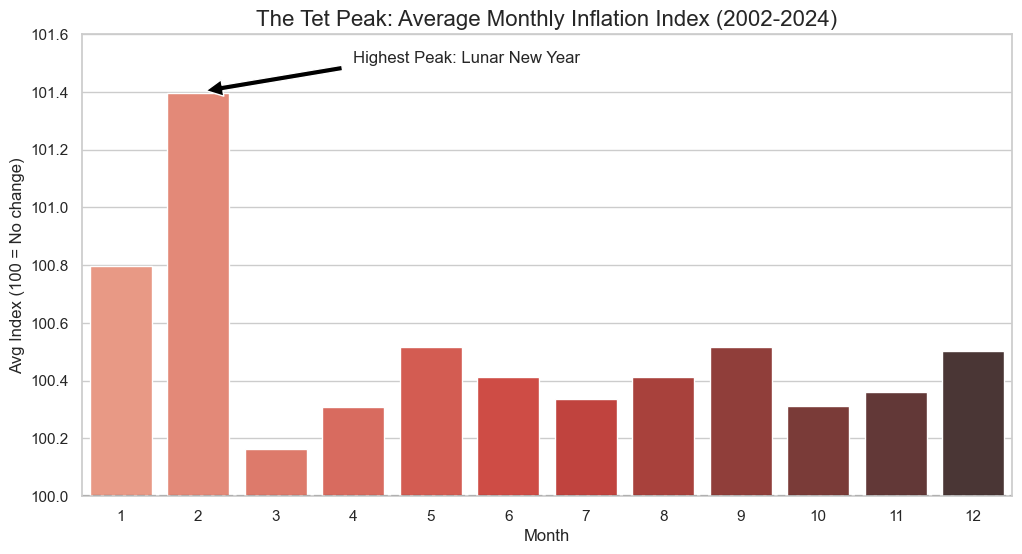

In [8]:
# Average monthly index across all 22 years
monthly_avg = total_cpi.groupby('Month')['Index_Value'].mean().reset_index()

plt.figure(figsize=(12, 6))
barplot = sns.barplot(data=monthly_avg, x='Month', y='Index_Value', palette='Reds_d')
plt.axhline(100, color='black', linestyle='--')
plt.ylim(100, 101.6)
plt.title('The Tet Peak: Average Monthly Inflation Index (2002-2024)', fontsize=16)
plt.ylabel('Avg Index (100 = No change)')

# Add annotation for Feb
plt.annotate('Highest Peak: Lunar New Year', xy=(1, 101.4), xytext=(3, 101.5),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()

## Pattern 2: Who Drives Chaos? (Volatility Analysis)
We compare which commodity groups are stable (Healthcare/Education) vs. which ones are highly volatile (Gold/Transport).

C:\Users\Alan Rexcop\AppData\Local\Temp\ipykernel_18060\677144607.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=volatility, y='Category', x='Index_Value', palette='viridis')


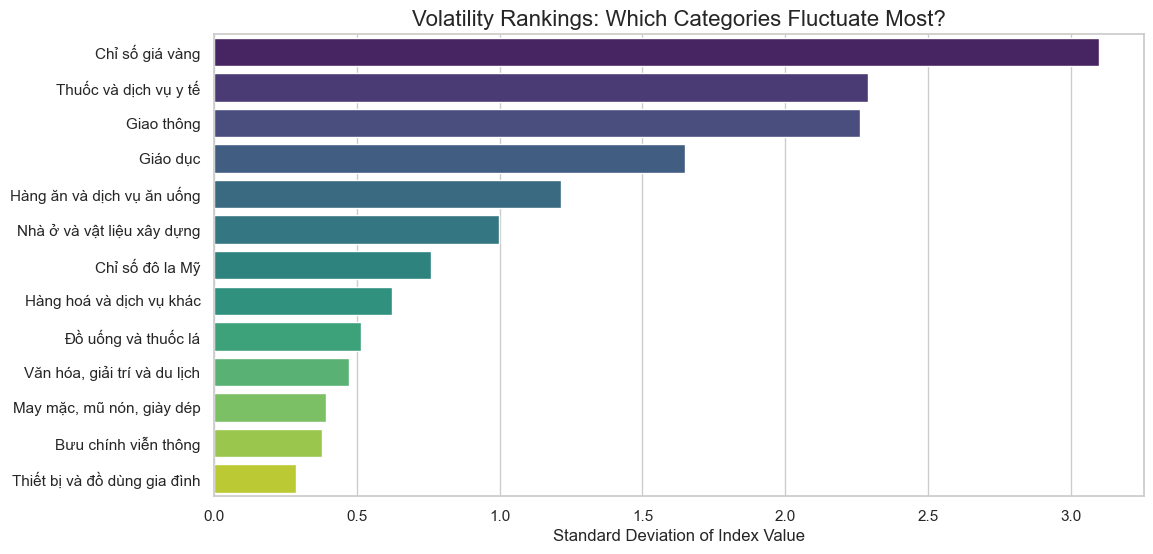

In [9]:
# Calculate Standard Deviation for each main category
volatility = main_cats.groupby('Category')['Index_Value'].std().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=volatility, y='Category', x='Index_Value', palette='viridis')
plt.title('Volatility Rankings: Which Categories Fluctuate Most?', fontsize=16)
plt.xlabel('Standard Deviation of Index Value')
plt.ylabel('')
plt.show()

## Pattern 3: Historical "Super-Peaks"
Visualizing the 2008 Financial Crisis and 2011 inflation spikes vs. the relative stability of the COVID-19 era.

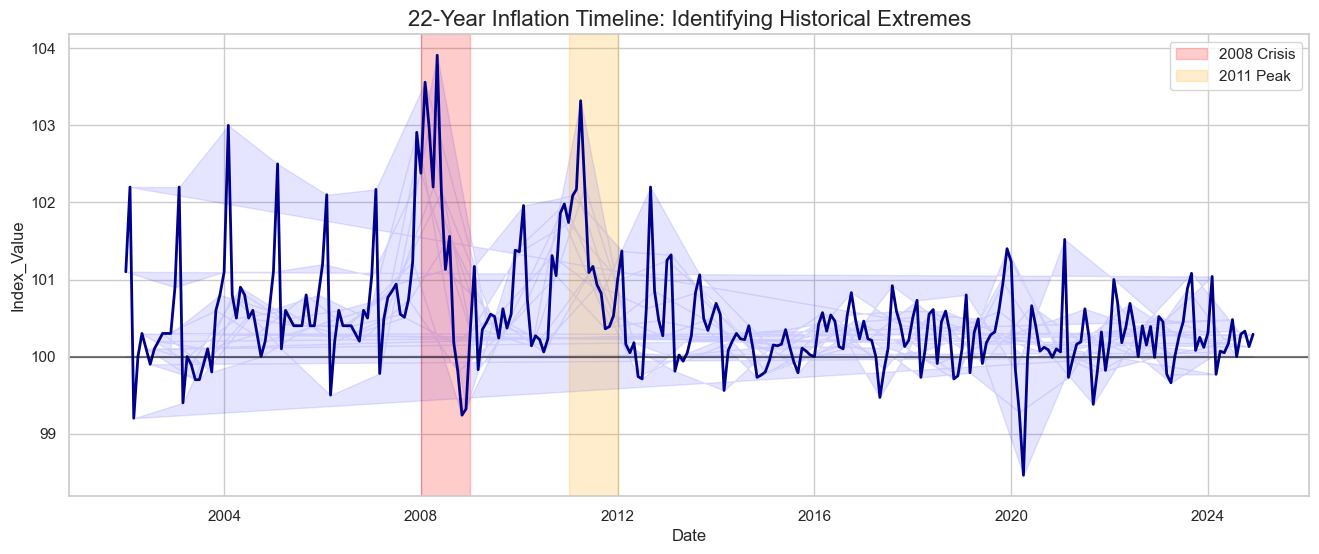

In [10]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=total_cpi, x='Date', y='Index_Value', color='darkblue', linewidth=2)
plt.fill_between(total_cpi['Date'], 100, total_cpi['Index_Value'], alpha=0.1, color='blue')

# Marking crisis areas
plt.axvspan(pd.Timestamp('2008-01-01'), pd.Timestamp('2008-12-31'), color='red', alpha=0.2, label='2008 Crisis')
plt.axvspan(pd.Timestamp('2011-01-01'), pd.Timestamp('2011-12-31'), color='orange', alpha=0.2, label='2011 Peak')

plt.axhline(100, color='black', linestyle='-', alpha=0.5)
plt.title('22-Year Inflation Timeline: Identifying Historical Extremes', fontsize=16)
plt.legend()
plt.show()

## Pattern 4: Heatmap of Economic Intensity
A bird's eye view of every single month since 2002. Darker red indicates higher inflation.

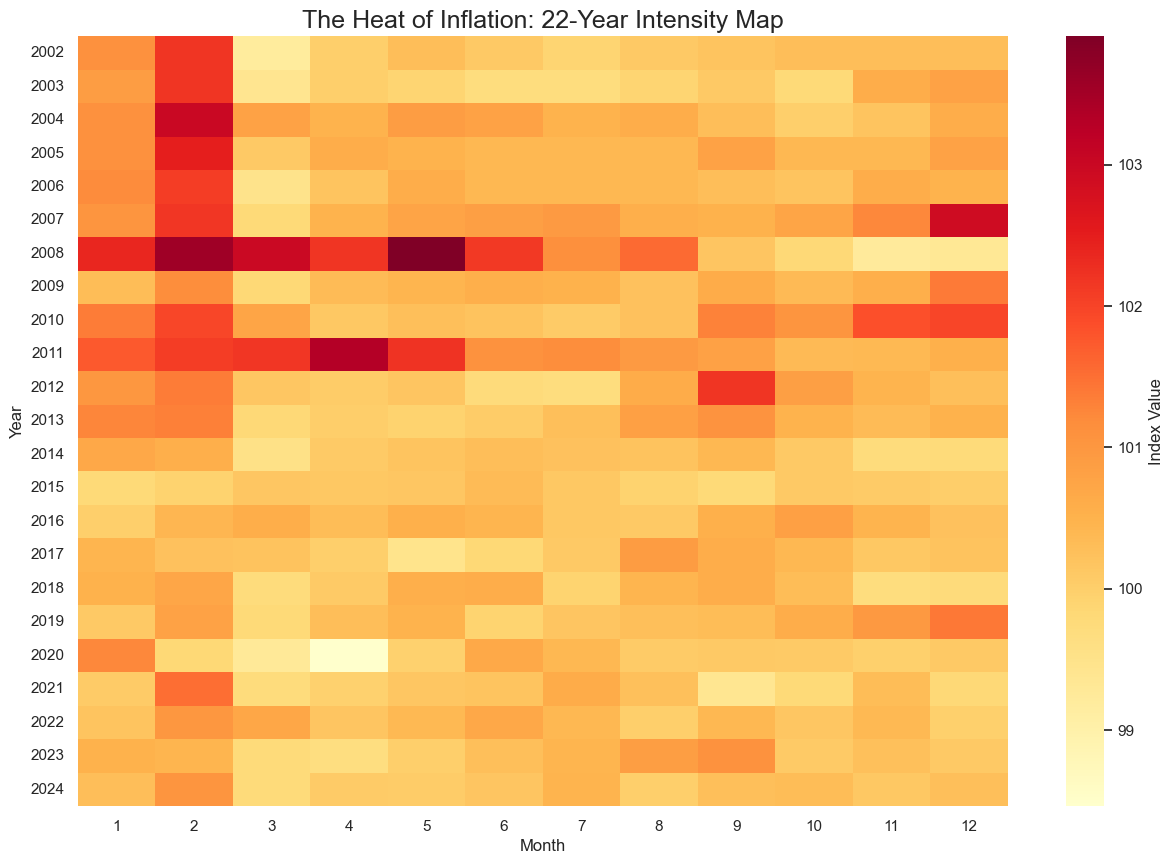

In [11]:
pivot_df = total_cpi.pivot(index="Year", columns="Month", values="Index_Value")

plt.figure(figsize=(15, 10))
sns.heatmap(pivot_df, cmap="YlOrRd", annot=False, cbar_kws={'label': 'Index Value'})
plt.title('The Heat of Inflation: 22-Year Intensity Map', fontsize=18)
plt.show()

## Pattern 5: Sympathetic Movements (Correlations)
How do Gold and the USD correlate with general CPI? (Hint: Gold often acts differently).

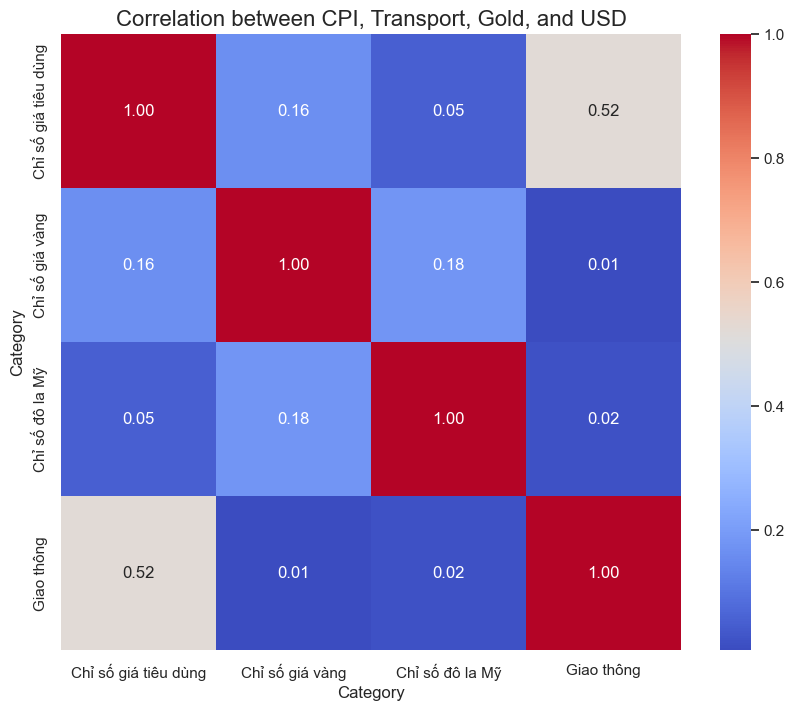

In [ ]:
# Extract key indices for correlation
corr_df = df[df['Category'].isin(['Chỉ số giá tiêu dùng', 'Chỉ số giá vàng', 'Chỉ số đô la Mỹ', 'Giao thông'])]
corr_pivot = corr_df.pivot_table(index=['Year', 'Month'], columns='Category', values='Index_Value').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_pivot, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation between CPI, Transport, Gold, and USD', fontsize=16)
plt.show()